**Tools**

In [1]:
!pip install resampy librosa
!pip install tensorflow
!pip install keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm
import librosa as lr
from keras.models import Sequential,load_model
from keras.layers import Dense,Conv1D,Dropout,Flatten,MaxPooling1D,BatchNormalization
from keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from keras.optimizers import Adam
from keras.utils import plot_model,to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix,classification_report

2025-12-13 21:38:32.255517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765661912.465784      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765661912.524148      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**Loading Data**

In [3]:
def extract_features(audio_path):
    audio,sample_rate = lr.load(audio_path, res_type='kaiser_fast')
    mfccs = lr.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=128)
    return np.mean(mfccs.T, axis=0)
def load_data(data,path):
    features,target = [],[]
    for index,row in tqdm(data.iterrows(),desc="Audio Loading"):
        audio_path = os.path.join(path,row['Filename'])
        features.append(extract_features(audio_path))
        target.append(row["Class"])
    return np.array(features),np.array(target)

In [4]:
train_data = pd.read_csv('/kaggle/input/audio-speech-sentiment/TRAIN.csv')
train_path = '/kaggle/input/audio-speech-sentiment/TRAIN/'
X,y = load_data(train_data,train_path)

Audio Loading: 250it [00:29,  8.39it/s]


**EDA**

In [5]:
pd.DataFrame({"Target":y}).value_counts()

Target  
Negative    87
Positive    82
Neutral     81
Name: count, dtype: int64

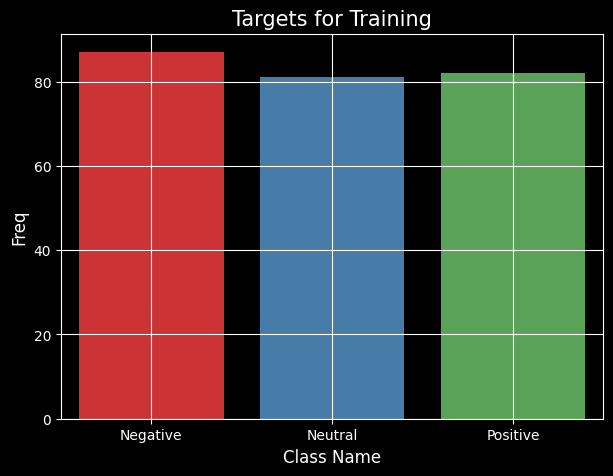

In [6]:
plt.style.use("dark_background")
plt.figure(figsize=(7,5))
sns.countplot(x="Target",data=pd.DataFrame({"Target":y}),palette="Set1")
plt.title("Targets for Training",fontsize=15)
plt.xlabel("Class Name",fontsize=12)
plt.ylabel("Freq",fontsize=12)
plt.grid(True)
plt.show()

In [7]:
def waveform(data,sr,label):
    plt.figure(figsize=(14, 5))
    lr.display.waveshow(data, sr=sr)
    plt.suptitle(label,y=1)
    plt.title('Waveform plot')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
#Mel-spectrogram
def Mel(data, sr):
    mel_spec = lr.feature.melspectrogram(y=data, sr=sr)
    return np.mean(mel_spec), mel_spec
def mel_v(mel_spec,label,sr):
    # Convert to decibel scale
    mel_spec_db = lr.power_to_db(mel_spec, ref=np.max)
    # Visualize Mel-spectrogram
    plt.figure(figsize=(10, 4))
    lr.display.specshow(mel_spec_db, x_axis='time', y_axis='mel', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-spectrogram')
    plt.suptitle(label,y=1)

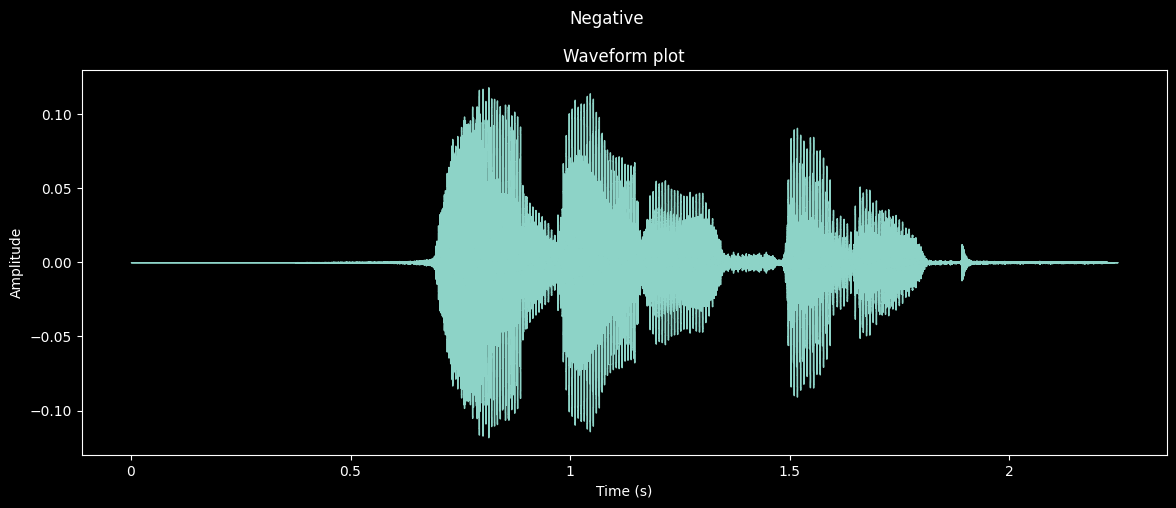

In [8]:
#waveform data[0]
audio_path = os.path.join(train_path,train_data["Filename"].iloc[0])
audio,sample_rate = lr.load(audio_path, res_type='kaiser_fast')
waveform(audio,sample_rate,y[0])

Mel Mean: 0.10836038
Mel : (128, 97)


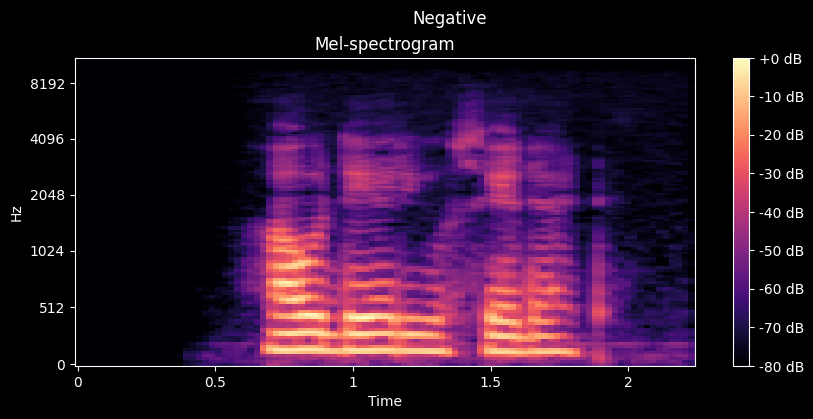

In [9]:
##Mel-spectrogram data[0]
mel_mean,mel= Mel(audio,sample_rate)
print('Mel Mean:',mel_mean)
print('Mel :',mel.shape)
mel_v(mel,y[0],sample_rate)

**Preprocessing**

In [10]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
X = np.expand_dims(X, axis=-1)

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=44,shuffle=True)
print(f"X Train Size: {X_train.shape} , X Test Size: {X_test.shape} , Y Train Size: {y_train.shape} , Y Test Size: {y_test.shape}")

X Train Size: (200, 128, 1) , X Test Size: (50, 128, 1) , Y Train Size: (200,) , Y Test Size: (50,)


**CNN Model**

In [12]:
num_class=len(pd.unique(y))

model = Sequential()

model.add(Conv1D(16, 3, activation='relu', input_shape=(128, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_class, activation="softmax"))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1765661956.656749      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1008)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        64,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,835 (253.26 KB)

 Trainable params: 64,835 (253.26 KB)

 Non-trainable params: 0 (0.00 B)

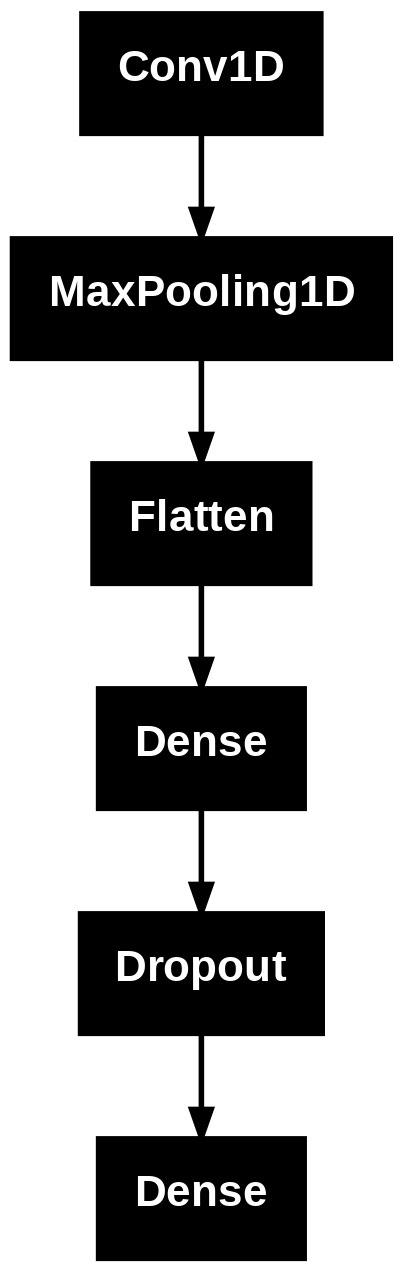

In [13]:
plot_model(model=model)

In [14]:
model.compile(optimizer=Adam(learning_rate=.001),loss="sparse_categorical_crossentropy"
              ,metrics=["accuracy"])
early_stopping = EarlyStopping(
    patience=5,restore_best_weights=True,verbose=1
)
save_point = ModelCheckpoint(
    "audio.keras",save_best_only=True,verbose=1
)
lr = ReduceLROnPlateau(
    factor=.3,patience=5,min_lr=1e-7,verbose=1
)
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=.2,
    callbacks=[early_stopping, save_point, lr]
)

Epoch 1/30


I0000 00:00:1765661959.114297      91 service.cc:148] XLA service 0x7c5350007be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765661959.114817      91 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765661959.324242      91 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/5 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.3125 - loss: 16.1255

I0000 00:00:1765661960.874530      91 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from inf to 2.96669, saving model to audio.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.3845 - loss: 12.1883 - val_accuracy: 0.4750 - val_loss: 2.9667 - learning_rate: 0.0010
Epoch 2/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4062 - loss: 9.3793
Epoch 2: val_loss improved from 2.96669 to 0.86775, saving model to audio.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4240 - loss: 7.5534 - val_accuracy: 0.6500 - val_loss: 0.8677 - learning_rate: 0.0010
Epoch 3/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4375 - loss: 5.9312
Epoch 3: val_loss improved from 0.86775 to 0.71931, saving model to audio.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4753 - loss: 5.7116 - val_accuracy: 0.7250 - val_loss: 0.7193 - learning_rate: 0.0010
Epoch 4/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6562 - loss: 3.0698
Epoch 4: val_loss did not improve from 0.71931
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0

In [15]:
hist = pd.DataFrame(history.history)
hist

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.38125,11.115181,0.475,2.966691,0.001
1,0.41250,7.318808,0.650,0.867747,0.001
2,0.49375,5.520947,0.725,0.719314,0.001
3,0.60625,3.067024,0.525,1.555681,0.001
4,0.64375,1.540209,0.800,0.480319,0.001
5,0.61250,1.661339,0.800,0.460592,0.001
6,0.71250,1.074221,0.700,0.950854,0.001
7,0.73750,0.803325,0.875,0.429221,0.001
8,0.70000,0.678744,0.800,0.428063,0.001
9,0.80000,0.460743,0.825,0.468364,0.001


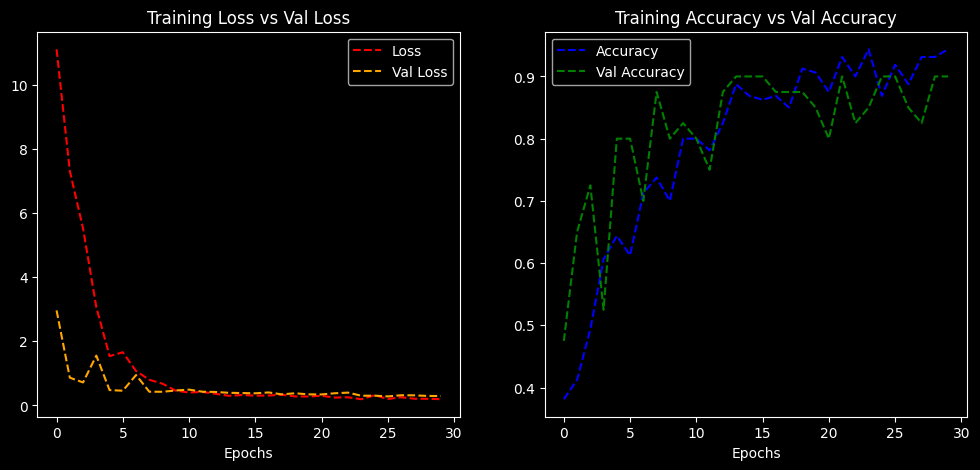

In [16]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist["loss"],'--',color="red")
plt.plot(hist["val_loss"],'--',color="orange")
plt.legend(["Loss","Val Loss"])
plt.title("Training Loss vs Val Loss",fontsize=12)
plt.xlabel("Epochs",fontsize=10)
plt.subplot(1,2,2)
plt.plot(hist["accuracy"],'--',color="blue")
plt.plot(hist["val_accuracy"],'--',color="green")
plt.legend(["Accuracy","Val Accuracy"])
plt.title("Training Accuracy vs Val Accuracy",fontsize=12)
plt.xlabel("Epochs",fontsize=10)
plt.show()

**Evaluation**

In [17]:
model = load_model("audio.keras")

In [18]:
loss,acc = model.evaluate(X_test,y_test)
print(f"Test Loss: {loss} , Test Accuracy: {acc}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - accuracy: 0.8917 - loss: 0.2737
Test Loss: 0.27312302589416504 , Test Accuracy: 0.8999999761581421


In [19]:
test_pred = model.predict(X_test)
y_pred = np.argmax(test_pred,axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


array([[15,  0,  2],
       [ 0, 15,  0],
       [ 3,  0, 15]])

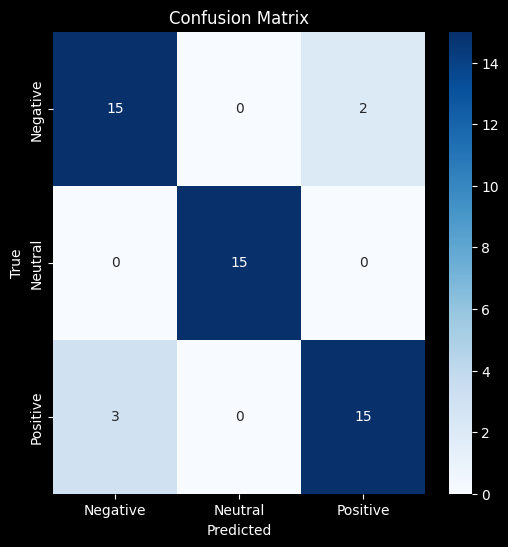

In [20]:
cm = confusion_matrix(y_test, y_pred)
# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show
cm

In [21]:
print("Classification Report:\n",classification_report(y_test,y_pred,target_names=encoder.classes_))

Classification Report:
               precision    recall  f1-score   support

    Negative       0.83      0.88      0.86        17
     Neutral       1.00      1.00      1.00        15
    Positive       0.88      0.83      0.86        18

    accuracy                           0.90        50
   macro avg       0.91      0.91      0.90        50
weighted avg       0.90      0.90      0.90        50

